## Data Cleaning and Storytelling - Eniac's discount strategy

In [1]:
#Importing packages
import pandas as pd
#import os

#Sets a flag to prevent archive code from running
RUN_ALL = True

#### Load Data

In [2]:
orders_raw = pd.read_csv('C:/Users/admin/Documents/1WBS/3Data_Cln_Stry/eniac_cleaning/data/raw/orders.csv')
orderlines_raw = pd.read_csv('C:/Users/admin/Documents/1WBS/3Data_Cln_Stry/eniac_cleaning/data/raw/orderlines.csv')
brands_raw = pd.read_csv('C:/Users/admin/Documents/1WBS/3Data_Cln_Stry/eniac_cleaning/data/raw/brands.csv')
products_raw = pd.read_csv('C:/Users/admin/Documents/1WBS/3Data_Cln_Stry/eniac_cleaning/data/raw/products.csv')

### Functions

In [3]:
#Function that can remove the first decimal from a number (formatted as a string), when there are two
def clean_double_decimal (df: pd.DataFrame, cols: list):
    for col in cols:
        mask = df[col].str.count('\.') > 1
        df.loc[mask, col] = df.loc[mask, col].str.replace('\.', '', n=1, regex=True)
    return (df)

### Basic data cleaning

In [4]:
#Recreate new copies of the tables for error checking

brands = brands_raw.copy().convert_dtypes()






## Clean Orders Data Frame

In [5]:
#Drop NA values from the orders table
orders = orders_raw.copy().dropna(axis=0).convert_dtypes()

#Change date in orders table to datetime
orders.created_date = pd.to_datetime(orders.created_date)

#include only completed orders
orders_completed = orders.loc[orders.state == 'Completed', :].copy()

#remove state column
orders_completed.drop('state', axis=1, inplace=True)

In [6]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 226904 entries, 0 to 226908
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   order_id      226904 non-null  Int64         
 1   created_date  226904 non-null  datetime64[ns]
 2   total_paid    226904 non-null  Float64       
 3   state         226904 non-null  string        
dtypes: Float64(1), Int64(1), datetime64[ns](1), string(1)
memory usage: 9.1 MB


## Clean orderlines DataFrame

In [7]:
#Make date a date type
orderlines = orderlines_raw.copy().convert_dtypes()
orderlines["date"] = pd.to_datetime(orderlines["date"])
#Remove double decimals from orderlines unit price
orderlines = clean_double_decimal(orderlines, ['unit_price'])
#Convert unit price to numeric
orderlines["unit_price"] = pd.to_numeric(orderlines["unit_price"])
#Remove the useless product_id column
orderlines.drop('product_id', axis=1, inplace=True)
#Rename order_id for better merging
orderlines.rename({'id_order' : 'order_id'}, inplace=True, axis=1)
orderlines.info()
orderlines.to_csv(
    'C:/Users/admin/Documents/1WBS/3Data_Cln_Stry/eniac_cleaning/data/interim/orderlines_cl.csv',
    index=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293983 entries, 0 to 293982
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                293983 non-null  Int64         
 1   order_id          293983 non-null  Int64         
 2   product_quantity  293983 non-null  Int64         
 3   sku               293983 non-null  string        
 4   unit_price        293983 non-null  Float64       
 5   date              293983 non-null  datetime64[ns]
dtypes: Float64(1), Int64(3), datetime64[ns](1), string(1)
memory usage: 14.6 MB


## Clean the products DataFrame

price
1    6942
0    3215
2     377
Name: count, dtype: Int64
promo_price
1    5812
2    4597
0     125
Name: count, dtype: Int64
price
1    7319
0    3215
Name: count, dtype: Int64
promo_price
1    10409
0      125
Name: count, dtype: Int64
Axes(0.125,0.11;0.775x0.77)


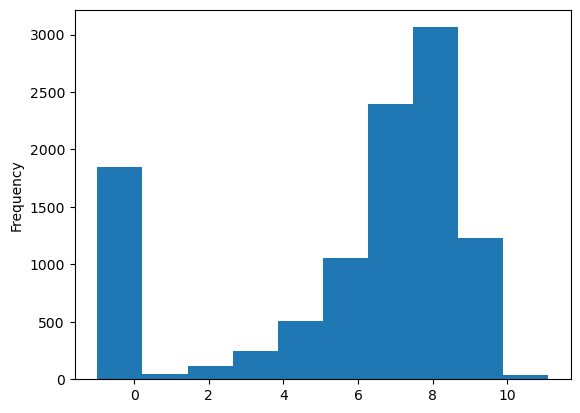

In [8]:
#Drop duplicates from the products table and autoupdate data types
products = products_raw.copy().drop_duplicates().convert_dtypes()

#Drop missing values from the price column  (but not missing descriptions or types)
products.dropna(subset='price', inplace=True)

#Clean up the issue with double periods

#test beforehand
print(products.price.str.count('\.').value_counts())
print(products.promo_price.str.count('\.').value_counts())
#Run custom function
products = clean_double_decimal(products, ['price', 'promo_price'])
#Test after
print (products.price.str.count('\.').value_counts())
print(products.promo_price.str.count('\.').value_counts())

#Now we can change the price and promo_price to floats
products[['price', 'promo_price']] = products[['price', 'promo_price']].astype(float)

print((products.promo_price / products.price - 1).plot.hist())

#drop promo price
products.drop('promo_price', axis=1, inplace=True)

### Add number of times each product has been sold from the orderlines table to product table
prod_times_sold = orderlines.groupby('sku', as_index=False).agg(times_sold=('sku', 'size'))
products = products.merge(prod_times_sold, on='sku', how='left')



In [9]:
products_raw.info()
products1 = products_raw.copy().drop_duplicates().convert_dtypes()
products2 = products1.dropna(subset='price')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19326 entries, 0 to 19325
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   sku          19326 non-null  object
 1   name         19326 non-null  object
 2   desc         19319 non-null  object
 3   price        19280 non-null  object
 4   promo_price  19326 non-null  object
 5   in_stock     19326 non-null  int64 
 6   type         19276 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.0+ MB


In [10]:
#Merge products and orderlines to compare price with unit price

merge = orderlines.merge(products, on='sku')
merge['check'] = merge.unit_price/merge.price
merge.check[merge.check > 1]

30        1.203443
44        1.173565
56        1.173565
63        1.007205
95        1.173565
            ...   
291337    1.025003
291672    1.072194
291830    1.001112
292117    1.001603
292339    1.025003
Name: check, Length: 11687, dtype: Float64

## Join Tables

In [11]:

#Merge (completed) orders with orderlines
orders_lines = orderlines.merge(orders  , on='order_id', how='inner') 
#Merge this table with the products table
full_df = orders_lines.merge(products, on='sku', how='inner')


#orderlines.columns

### Add custom columns

In [12]:
full_df['discount'] = full_df.price - full_df.unit_price
full_df['discount_per'] = full_df.discount/full_df.price * 100

### Exploration of discounts and discount%

<Axes: ylabel='Frequency'>

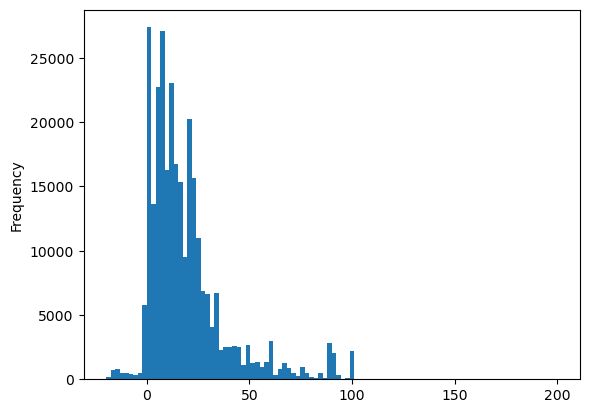

In [13]:
#histogram of discounts
full_df.loc[full_df.discount_per > -20, "discount_per"].plot.hist(bins=100)




### Loop through products to find average discount, day discount, etc.

In [14]:
top_10_selling[0]
df = full_df[full_df.sku == top_10_selling[0]]
plot_data = (df.resample('W', on= 'date')
 .agg(mean_unit_price=("unit_price", "mean"), 
      quantity_sold = ('product_quantity', 'sum'))
 .reset_index()
)
plot_data.plot.scatter(x='mean_unit_price', y='quantity_sold')

NameError: name 'top_10_selling' is not defined

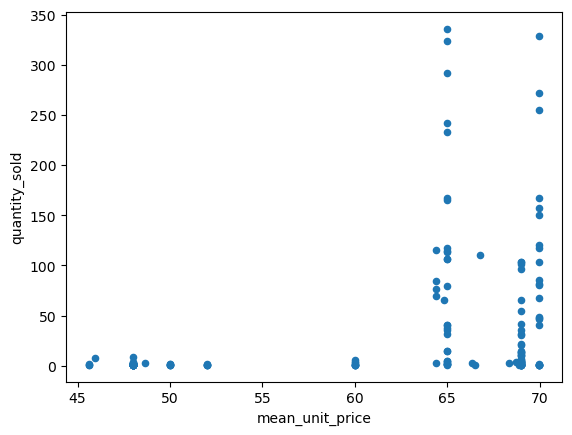

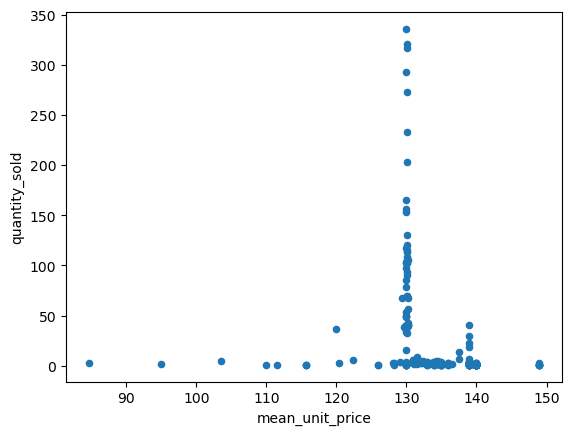

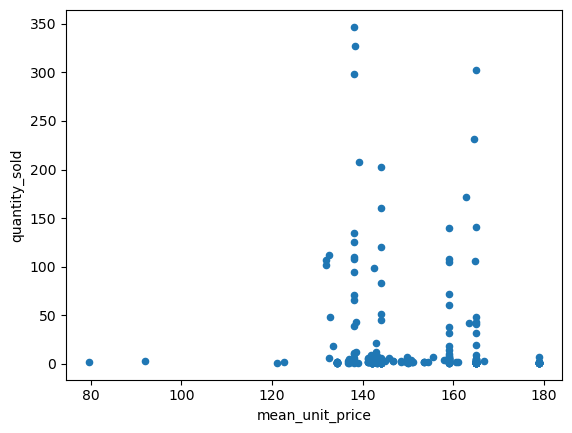

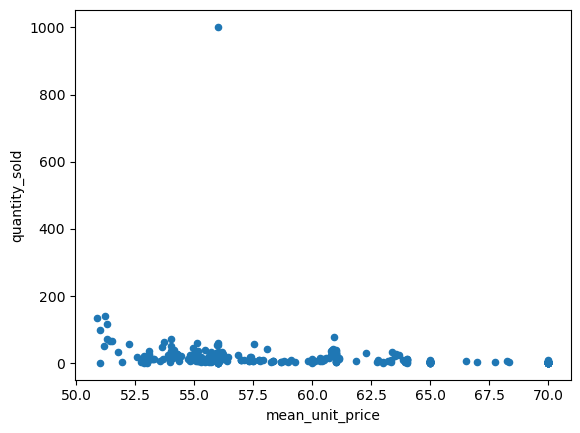

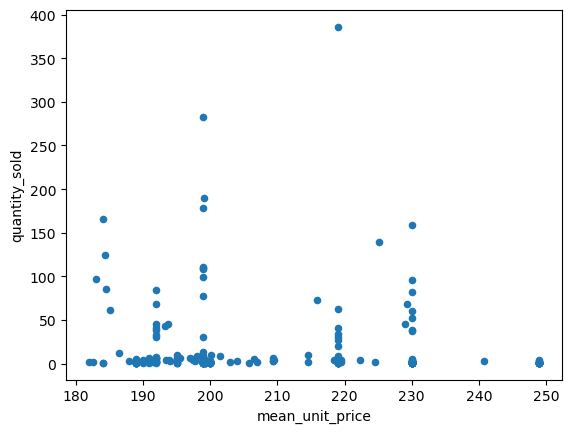

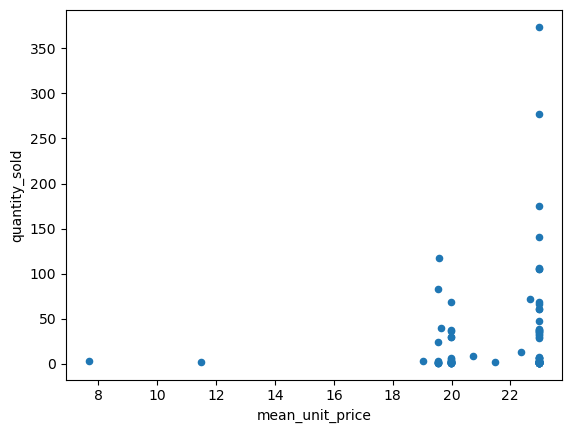

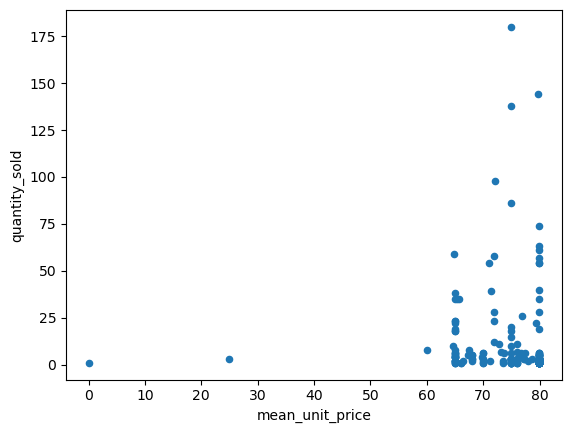

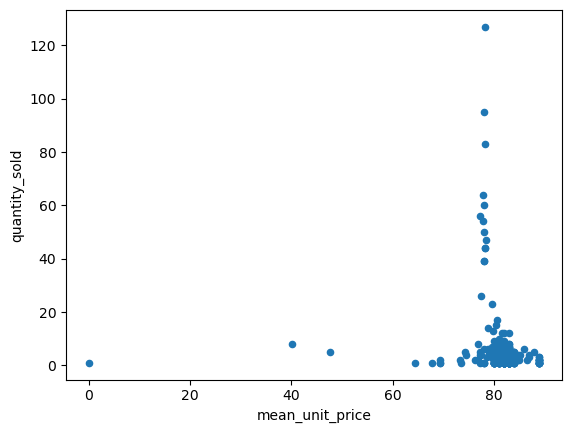

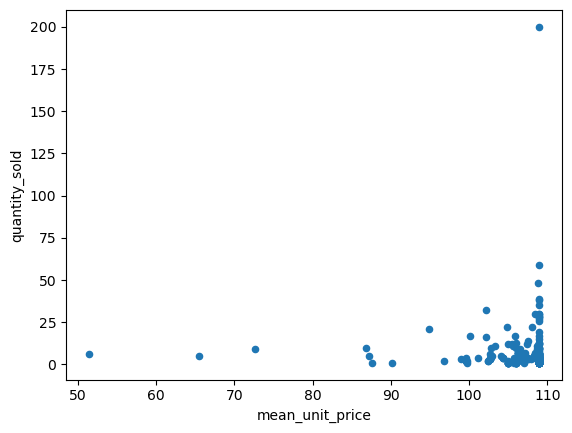

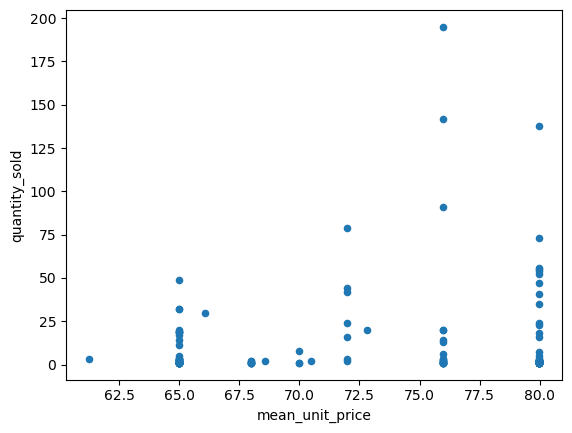

: 

In [ ]:
top_10_selling = list(products.sort_values('times_sold', ascending=False).head(10).sku)

for _sku in top_10_selling:
    df = full_df[full_df.sku == _sku]
    plot_data = (df.resample('d', on= 'date')
        .agg(mean_unit_price=("unit_price", "mean"), 
            quantity_sold = ('product_quantity', 'sum'))
        .reset_index()
    )
    plot_data.plot.scatter(x='mean_unit_price', y='quantity_sold')

In [ ]:
prod_times_sold_test = full_df.groupby('sku', as_index=False).agg(times_sold=('sku', 'size')) 
orderlines[orderlines.sku == 'MIC0036']

,id,order_id,product_quantity,sku,unit_price,date
1951,1123099,301369,1,MIC0036,47.99,2017-01-03 10:25:22
5162,1133936,304346,1,MIC0036,47.99,2017-01-07 17:29:36
5361,1134421,304538,1,MIC0036,52.0,2017-01-07 23:00:21
9681,1143616,308384,1,MIC0036,47.99,2017-01-13 08:00:25
10934,1146128,309471,1,MIC0036,47.99,2017-01-14 18:37:25
...,...,...,...,...,...,...
291708,1646166,525463,1,MIC0036,68.99,2018-03-11 15:20:08
292482,1647525,526105,1,MIC0036,68.99,2018-03-12 19:07:42
292835,1648164,526376,1,MIC0036,68.99,2018-03-13 12:06:53
292852,1648194,526390,1,MIC0036,68.99,2018-03-13 12:25:37


In [ ]:


prod_lst = list(set(full_df.sku))
_sku = prod_lst[0]
df = full_df[full_df.sku == _sku]

# for _sku in prod_set:
#     df = full_df[full_df.sku = _sku]

### Code blocks for exploration

In [ ]:
mask = products.price.astype(str).str.contains(r"\.\d{3,}$", regex=True)
three_dec = products[mask]

<Axes: ylabel='Frequency'>

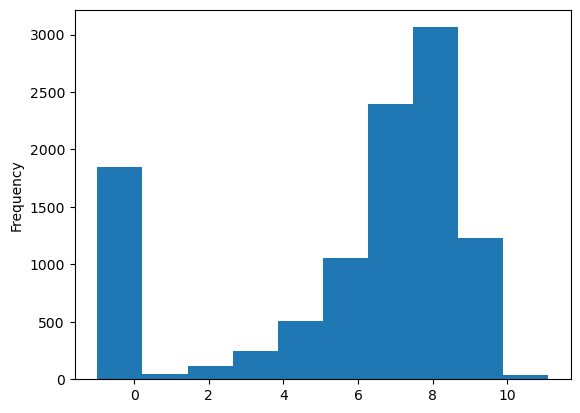

In [ ]:
# products['discount'] = products.promo_price / products.price - 1
# products.discount.plot.hist()

(products.promo_price / products.price - 1).plot.hist()

In [ ]:
products_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19326 entries, 0 to 19325
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   sku          19326 non-null  object
 1   name         19326 non-null  object
 2   desc         19319 non-null  object
 3   price        19280 non-null  object
 4   promo_price  19326 non-null  object
 5   in_stock     19326 non-null  int64 
 6   type         19276 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.0+ MB


In [ ]:
products.info()
products.sample(10)

<class 'pandas.core.frame.DataFrame'>
Index: 10534 entries, 0 to 19325
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sku          10534 non-null  string 
 1   name         10534 non-null  string 
 2   desc         10527 non-null  string 
 3   price        10534 non-null  float64
 4   promo_price  10534 non-null  float64
 5   in_stock     10534 non-null  Int64  
 6   type         10484 non-null  string 
 7   discount     10534 non-null  float64
dtypes: Int64(1), float64(3), string(4)
memory usage: 751.0 KB


,sku,name,desc,price,promo_price,in_stock,type,discount
11663,TRA0031-A,Open - Transcend JetDrive Lite 350 256GB Macbo...,MLC memory card 256GB Macbook Pro 15-inch Reti...,184.000,1645.823,0,1298,7.944690
19142,WDT0413,WD 240GB SSD NAND 3D Green SATA,240GB SSD SATA 3 (6Gb / s) for Mac and PC,85.000,769.947,1,12655397,8.058200
16148,ADN0049,Adonit Jot Mini 3.0 Pointer Black,Triangular pointer with clip design disc trans...,25.200,189.897,0,1229,6.535595
15476,REP0335,Repair iPad 3 Headphone Input,Repair service including parts and labor for i...,6999.003,69.990,0,"1,44E+11",-0.990000
1131,KAN0027,Kanex adapter Thunderbolt to eSATA + USB 3.0,Thunderbolt adapter cable to eSATA + USB 3.0.,104.990,999.896,1,12585395,8.523726
18527,WDT0401,WD My Cloud Home 4TB USB 3.0,centralized storage for Mac and PC,269.990,2380.046,0,11935397,7.815312
14929,PAC1907,Crucial MX300 expansion kit 2TB SSD + 16GB 160...,expansion kit 2TB SSD + 16GB 1600Mhz RAM for M...,7995.192,682.584,0,1433,-0.914626
10906,PAC1209,QNAP Pack HS-251 + | Seagate 4TB IronWolf,QNAP Pack HS-251 + with 4TB (2x2TB) IronWolf S...,618.970,5091.789,0,12175397,7.226229
11785,PAC1369,Synology Pack DS216J | Seagate 8TB IronWolf,NAS + 8TB (2x4TB) Seagate IronWolf for Mac and...,535.970,4221.787,0,12175397,6.876909
2415,FCM0007-4,Mac memory FCM 32GB (4x8GB) SO-DIMM DDR3 1333MHz,RAM 32GB (4x8GB) iMac (2010/11).,275.960,2709.904,0,1364,8.819916


## A big dump for dead code in case I want to come back to it

In [ ]:
#RUN_ALL = False

In [ ]:
if not RUN_ALL:
    mask = products.price.str.count('\.') > 1
    a = products.loc[mask, 'price'].str.replace('\.', '', n=1, regex=True)
    #a = a.str.replace('\.', '')
    a
    b = clean_double_decimal(products, 'price')
    b.price.str.count('\.').value_counts()



    #Check for and drop rows where price is missing
    products[products.isna().any(axis=1)].isna().value_counts()
